In [1]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM

device = "cuda" # for GPU usage or "cpu" for CPU usage
checkpoint = "HuggingFaceTB/SmolLM2-135M"

# Download and load SmolLM2
model = AutoModelForCausalLM.from_pretrained(checkpoint).to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [2]:
W = []

for n, m in model.named_modules():
    if isinstance(m, nn.Linear) and "lm_head" not in n:
        # Detach, move to CPU, and convert to numpy
        W = m.weight.data.detach().cpu().float().numpy()
        print(f"Matrix shape: {W.shape} {n}")

print(f"Matrix shape: {W.shape}")

Matrix shape: (576, 576) model.layers.0.self_attn.q_proj
Matrix shape: (192, 576) model.layers.0.self_attn.k_proj
Matrix shape: (192, 576) model.layers.0.self_attn.v_proj
Matrix shape: (576, 576) model.layers.0.self_attn.o_proj
Matrix shape: (1536, 576) model.layers.0.mlp.gate_proj
Matrix shape: (1536, 576) model.layers.0.mlp.up_proj
Matrix shape: (576, 1536) model.layers.0.mlp.down_proj
Matrix shape: (576, 576) model.layers.1.self_attn.q_proj
Matrix shape: (192, 576) model.layers.1.self_attn.k_proj
Matrix shape: (192, 576) model.layers.1.self_attn.v_proj
Matrix shape: (576, 576) model.layers.1.self_attn.o_proj
Matrix shape: (1536, 576) model.layers.1.mlp.gate_proj
Matrix shape: (1536, 576) model.layers.1.mlp.up_proj
Matrix shape: (576, 1536) model.layers.1.mlp.down_proj
Matrix shape: (576, 576) model.layers.2.self_attn.q_proj
Matrix shape: (192, 576) model.layers.2.self_attn.k_proj
Matrix shape: (192, 576) model.layers.2.self_attn.v_proj
Matrix shape: (576, 576) model.layers.2.self_at

In [3]:
# Import our algorithms for pruning
from tetris import tetris_pruning, original_tetris_pruning, random_swaps_find_mask, sort_columns_by_norm, block_sparsity_pruning

In [4]:
def benchmark_run(alg_name, pruning_func, *args, **kwargs):
    print(f"Running {alg_name}...", end="", flush=True)
    
    # Calculate baseline score for t=0 (Standard Pruning)
    _, mask_std = block_sparsity_pruning(args[0], kwargs.get('block_size', (1, 8)), kwargs.get('sparsity', 0.5))
    start_score = np.abs(args[0])[mask_std == 0].sum()

    start_time = time.perf_counter()
    result = pruning_func(*args, **kwargs) 
    total_time = time.perf_counter() - start_time
    print(f" Done! ({total_time:.4f}s)")
    
    convergence_time = total_time
    if len(result) > 3:
        convergence_time = result[3]

    history = result[4] if len(result) > 4 else None
    after_tetris_index_in_history = result[5] if len(result) > 5 else None

    # If no history (non-iterative alg), create synthetic history [Start -> End]
    if history is None:
        final_score = np.abs(result[0])[result[1]==0].sum()
        history = [(0.0, start_score), (total_time, final_score)]

    return {
        "Algorithm": alg_name,
        "Total Time": total_time,
        "Convergence Time": convergence_time,
        "Pruned": history[-1][1],
        "Original Pruned": history[0][1],
        "Improvement %": ((history[0][1] - history[-1][1]) / history[0][1] * 100),
        "History": history,
        "Tetris Index": after_tetris_index_in_history
    }

In [7]:
W_test = []
i = 0
for n, m in model.named_modules():
    if type(m) == nn.Linear and "lm_head" not in n:
        if (i == 3):
            print(f"Benchmark matrix shape: {W_test.shape}")
            break
        W_test = m.weight.data.detach().cpu().float().numpy()
        i += 1

BLOCK_SIZE_BENCH = (1, 8)
SPARSITY_BENCH = 0.5
MAX_ITER_BENCH = 100
RANDOM_SWAPS_BENCH = 5000

# Our tetris
stats_our_tetris = benchmark_run(
    "Our Tetris",
    tetris_pruning,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH,
    random_swaps=RANDOM_SWAPS_BENCH,
    verbose=True
)

# Random swaps
stats_random_swaps = benchmark_run(
    "Random Swaps",
    random_swaps_find_mask,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH + RANDOM_SWAPS_BENCH,
    verbose=True
)

# Original tetris
stats_original_tetris = benchmark_run(
    "Original Tetris",
    original_tetris_pruning,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH,
    verbose=False
)

# Sort columns by L1 norm
stats_sort_columns_by_norm = benchmark_run(
    "Sort Columns by L1 Norm",
    sort_columns_by_norm,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    verbose=False
)


# print(stats_our_tetris)
# print(stats_random_swaps)
# print(stats_original_tetris)
# print(stats_sort_columns_by_norm)

Benchmark matrix shape: (192, 576)
Running Our Tetris...

BLOCK                    TETRIS                   DIFF                     DIFF %                   TOTAL DIFF %             
1274.2058105469          1204.9448242188          69.2609863281            5.4356198311             5.4356198311             
1069.9643554688          1050.2425537109          19.7218017578            1.8432203531             17.5766944885            
1023.6713867188          1022.8716430664          0.7997436523             0.0781250373             19.7247695923            
1018.7464599609          1018.7330932617          0.0133666992             0.0013120732             20.0495643616            
1017.1037597656          1017.6514282227          -0.5476684570            -0.0538458824            20.1344528198            
1015.8461914062          1016.1907348633          -0.3445434570            -0.0339168906            20.2490901947            
1014.9373779297          1014.9462280273          -0.0088500977            -0.0008719846            20.3467597961     

In [8]:
def print_benchmark_results(results_list):
    if not isinstance(results_list, list):
        results_list = [results_list]

    # Header
    print(f"{'ALGORITHM':<25} {'PRUNED ABS SUM':<16} {'TOT IMP [%]':<15} {'TOT TIME':<12} {'CONV TIME':<12} {'TIME >95% (Conv %)':<25} {'IMP @ 95% [%]':<10}")
    print("-" * 130)

    for res in results_list:
        name = res.get("Algorithm", "Unknown")
        
        # Get basic stats (handle missing values)
        pruned = res.get("Pruned") or 0
        total_improv = res.get("Improvement %") or 0
        total_t = res.get("Total Time") or 0
        conv_t = res.get("Convergence Time") or 0
        history = res.get("History", [])

        # Default values (if history is missing)
        time_95 = conv_t
        conv_pct_at_95 = 100.0
        improv_at_95 = total_improv

        if history and len(history) > 1:
            start_score = history[0][1]
            final_score = history[-1][1]
            total_gain = start_score - final_score
            
            if total_gain > 0:
                target_score = start_score - (total_gain * 0.95)
                
                # Find the first moment we crossed the 95% threshold
                for t, score in history:
                    if score <= target_score:
                        time_95 = t
                        
                        # 1. How much of the total convergence is done? (e.g. 95.2%)
                        current_gain = start_score - score
                        conv_pct_at_95 = (current_gain / total_gain) * 100
                        
                        # 2. What is the improvement relative to baseline? (e.g. 19.2%)
                        improv_at_95 = (current_gain / start_score) * 100
                        break

        # Format the time string: "6.1821 (95.2%)"
        time_str = f"{time_95:.4f} ({conv_pct_at_95:.1f}%)"

        print(f"{name:<25} {pruned:<16.4f} {total_improv:<15.2f} {total_t:<12.4f} {conv_t:<12.4f} {time_str:<25} {improv_at_95:<10.2f}")

# Usage:
print_benchmark_results([stats_our_tetris, stats_random_swaps, stats_original_tetris, stats_sort_columns_by_norm])

ALGORITHM                 PRUNED ABS SUM   TOT IMP [%]     TOT TIME     CONV TIME    TIME >95% (Conv %)        IMP @ 95% [%]
----------------------------------------------------------------------------------------------------------------------------------
Our Tetris                979.9592         23.09           172.4369     144.8827     9.7842 (95.1%)            21.97     
Random Swaps              1100.4585        13.64           5.0168       4.8830       3.6070 (95.7%)            13.05     
Original Tetris           1016.9305        20.19           0.7584       0.5020       0.4793 (98.2%)            19.84     
Sort Columns by L1 Norm   1008.7502        20.83           0.0019       0.0019       0.0019 (100.0%)           20.83     


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_comparison(stats_list, matrix_shape):
    """
    Plots a comparison of multiple pruning algorithms.
    Accepts a single stats dict or a list of stats dicts.
    
    Displays:
    1. Convergence History (Line Plot) with "Wasted Time" visualization.
    2. Time Audit (Bar Chart) comparing Convergence Time vs Total Time.
    """
    # Ensure input is a list
    if not isinstance(stats_list, list):
        stats_list = [stats_list]

    # Create Subplots (2 Rows)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Default matplotlib colors
    
    # ==========================================
    # GRAPH 1: CONVERGENCE HISTORY
    # ==========================================
    
    for i, stats in enumerate(stats_list):
        history = stats.get("History")
        alg_name = stats.get("Algorithm", f"Alg {i}")
        total_time = stats.get("Total Time")
        conv_time = stats.get("Convergence Time")
        tetris_idx = stats.get("Tetris Index")
        color = colors[i % len(colors)]
        
        if not history:
            print(f"Skipping {alg_name}: No history found.")
            continue

        times = [h[0] for h in history]
        scores = [h[1] for h in history]
        final_score = scores[-1]

        # 1. Plot the Active Convergence (Solid Line)
        ax1.plot(times, scores, linewidth=2, color=color, label=f"{alg_name} (Active)")
        
        # 2. Plot the "Wasted Time" (Dashed Line to Total Time)
        # Only if there is a visible difference (> 1% of time)
        if total_time and (total_time - times[-1]) > (total_time * 0.01):
            ax1.plot([times[-1], total_time], [final_score, final_score], 
                     linestyle='--', linewidth=2, color=color, alpha=0.6, 
                     label=f"{alg_name} (Wasted Time)")
            
            # Mark the actual End Time
            ax1.scatter([total_time], [final_score], marker='X', s=100, color=color, zorder=5)
            ax1.text(total_time, final_score, f" End ({total_time:.1f}s)", 
                     color=color, fontsize=9, verticalalignment='bottom')

        # 3. Mark the Tetris -> Random transition (if applicable)
        if tetris_idx is not None and tetris_idx < len(history):
            trans_time = times[tetris_idx]
            trans_score = scores[tetris_idx]
            ax1.scatter([trans_time], [trans_score], color=color, edgecolor='black', s=80, marker='o', zorder=10)
            if i == 0: # Only label once to avoid clutter
                ax1.text(trans_time, trans_score, " Tetris End", color=color, fontsize=9, fontweight='bold')

    # Formatting Graph 1
    ax1.set_title(f"Convergence Analysis for Matrix Shape {matrix_shape}", fontsize=14)
    ax1.set_ylabel("Sum of Pruned Weights (Lower is Better)", fontsize=12)
    ax1.set_xlabel("Time (seconds) - Log Scale", fontsize=12)
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    ax1.legend()
    ax1.set_xscale('log') 

    # force "General" number formatting on x-axis (instead of scientific notation)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

    # ==========================================
    # GRAPH 2: TIME AUDIT (BAR CHART)
    # ==========================================
    
    names = [s.get("Algorithm", f"Alg {i}") for i, s in enumerate(stats_list)]
    total_times = [s.get("Total Time", 0) for s in stats_list]
    conv_times = [s.get("Convergence Time", 0) for s in stats_list]
    
    y_pos = np.arange(len(names))
    
    # Plot Total Time (Background Bar)
    ax2.barh(y_pos, total_times, align='center', color='lightgray', label='Wasted Time')
    
    # Plot Convergence Time (Foreground Bar)
    ax2.barh(y_pos, conv_times, align='center', color=[colors[i % len(colors)] for i in range(len(names))], label='Time to Convergence')
    
    # Annotate bars
    for i, (tot, conv) in enumerate(zip(total_times, conv_times)):
        # Text inside the "Useful" bar
        ax2.text(conv / 2, i, f"{conv:.2f}s", color='white', fontweight='bold', ha='center', va='center')
        
        # Text at the end of the "Total" bar
        if tot > conv:
            diff = tot - conv
            ax2.text(tot + (tot*0.01), i, f"Total: {tot:.2f}s (+{diff:.2f}s buffer)", color='black', va='center')

    # Formatting Graph 2
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(names, fontsize=11, fontweight='bold')
    ax2.set_xlabel("Time (seconds)", fontsize=12)
    ax2.set_title(f"Time Efficiency: How fast did it actually find the solution? Shape {matrix_shape}", fontsize=14)
    ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

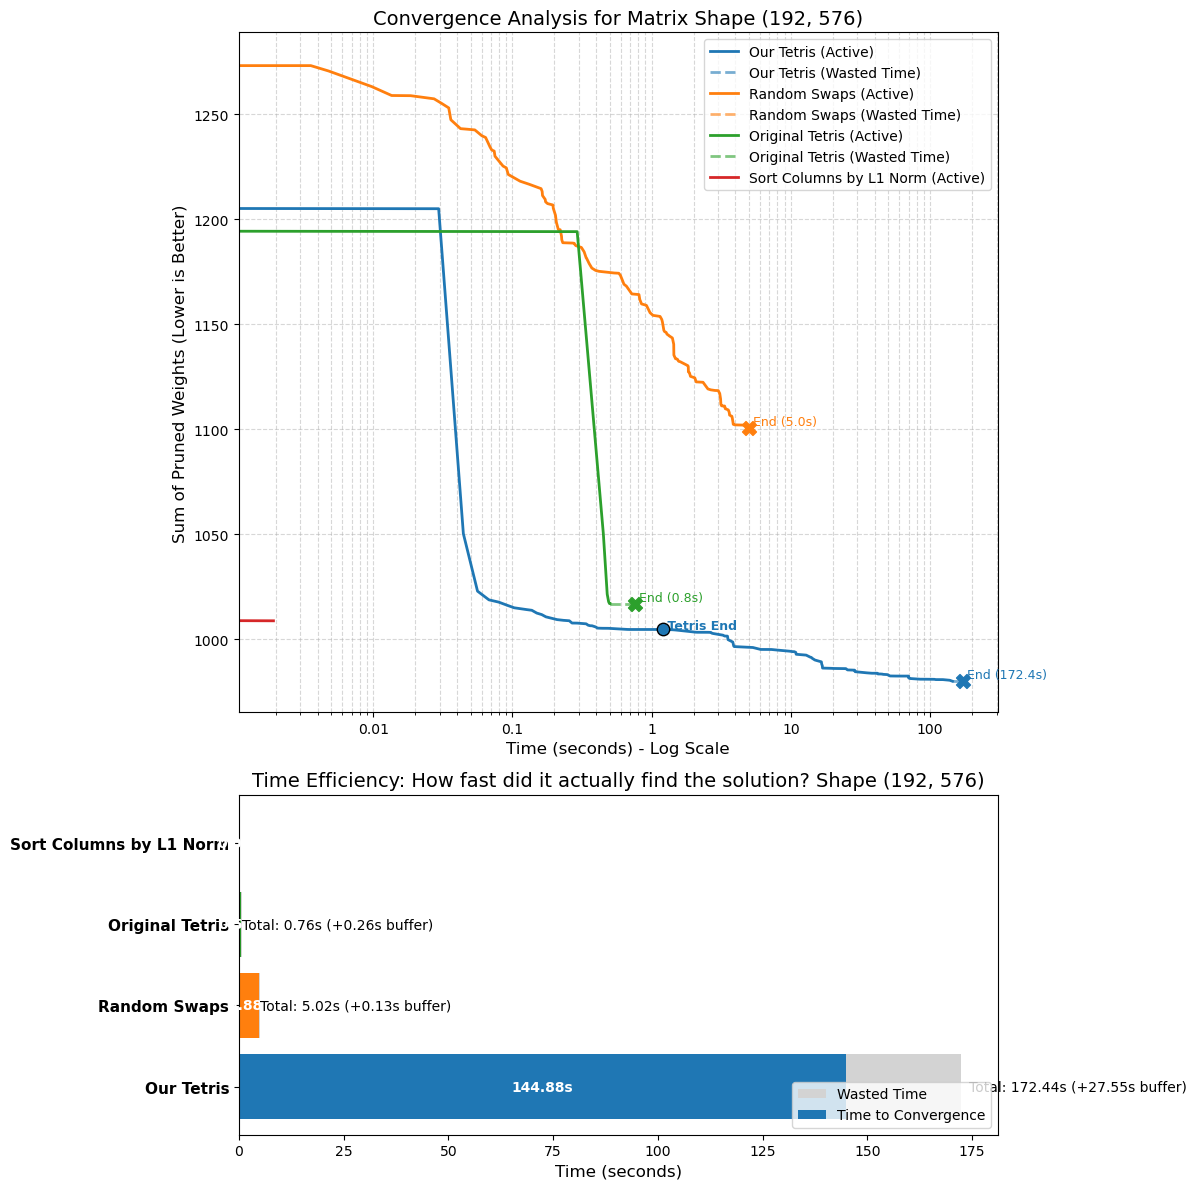

In [10]:
# Generate graphs
plot_comparison([stats_our_tetris, stats_random_swaps, stats_original_tetris, stats_sort_columns_by_norm], W_test.shape)